In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# III.Hospitalization_discharge (Komal's dataset starts here)

# 1. Load and take a first look

In [49]:
df3 = pd.read_csv("cardiac_failure/hospitalization_discharge.csv")
print("Shape:", df3.shape)
df3["inpatient_number"] = df3["inpatient_number"].astype(str)
df3.head()

Shape: (2008, 21)


,inpatient_number,destinationdischarge,admission_ward,admission_way,discharge_department,visit_times,respiratory_support,oxygen_inhalation,dischargeday,admission_date,...,death_within_28_days,re_admission_within_28_days,death_within_3_months,re_admission_within_3_months,death_within_6_months,re_admission_within_6_months,time_of_death__days_from_admission,readmission_time_days_from_admission,return_to_emergency_department_within_6_months,time_to_emergency_department_within_6_months
0,857781,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,11,2017-01-24 00:00:00,...,0,0,0,0,0,0,NaN,NaN,0.0,NaN
1,743087,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,8,2017-05-05 00:00:00,...,0,0,0,0,0,0,NaN,NaN,0.0,NaN
2,866418,Home,Cardiology,NonEmergency,Cardiology,2,NaN,OxygenTherapy,5,2016-11-18 00:00:00,...,0,0,0,0,0,0,NaN,NaN,0.0,NaN
3,775928,Home,Cardiology,Emergency,Cardiology,1,NaN,OxygenTherapy,11,2017-10-02 00:00:00,...,0,1,0,1,0,1,NaN,19.0,1.0,19.0
4,810128,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,5,2019-11-17 00:00:00,...,0,0,0,0,0,0,NaN,NaN,0.0,NaN


-The above code confirm with 2,008 hospitalization records across 21 variables — a mix of identifiers, categorical descriptors, and time-to-event outcomes. This is a classic survival/outcomes dataset structure (admission → discharge → downstream events like death or readmission), which shapes every decision that follows.

In [50]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 2008 entries, 0 to 2007
Data columns (total 21 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   inpatient_number                                2008 non-null   str    
 1   destinationdischarge                            2008 non-null   str    
 2   admission_ward                                  2008 non-null   str    
 3   admission_way                                   2008 non-null   str    
 4   discharge_department                            2008 non-null   str    
 5   visit_times                                     2008 non-null   int64  
 6   respiratory_support                             42 non-null     str    
 7   oxygen_inhalation                               2008 non-null   str    
 8   dischargeday                                    2008 non-null   int64  
 9   admission_date                                  2008

# 2. Check structure — duplicates and ID integrity

In [51]:
print("Fully duplicated rows:", df3.duplicated().sum())
print("Duplicate inpatient_number:", df3["inpatient_number"].duplicated().sum())

Fully duplicated rows: 0
Duplicate inpatient_number: 0


-Zero duplicate & inpatient_number values means each row is one hospitalization episode, not one patient (a patient could theoretically appear twice across different admissions — worth checking separately if patient-level analysis matters). Finding duplicates here would have signaled either a data export error or double-counted encounters, both of which would bias any incidence/rate calculation.

# 3. Handle missing values — deliberately, not blindly
*First inspect the pattern:

In [52]:
missing = df3.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df3) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
respiratory_support,1966,97.9
time_of_death__days_from_admission,1964,97.8
time_to_emergency_department_within_6_months,1111,55.3
readmission_time_days_from_admission,1107,55.1
return_to_emergency_department_within_6_months,1,0.0
discharge_department,0,0.0
admission_way,0,0.0
admission_ward,0,0.0
destinationdischarge,0,0.0
inpatient_number,0,0.0


In [53]:
df3["respiratory_support"] = df3["respiratory_support"].fillna("None")

-Respiratory_support being 98% empty doesn't mean 98% of records are broken — it means respiratory support (mechanical ventilation) is a rare intervention, and its absence is itself clinical information. Filling with "None" rather than dropping the column preserves that signal.

In [54]:
checks = [
    ("time_of_death__days_from_admission", "death_within_6_months"),
    ("readmission_time_days_from_admission", "re_admission_within_6_months"),
    ("time_to_emergency_department_within_6_months", "return_to_emergency_department_within_6_months"),
]
for time_col, flag_col in checks:
    mismatch = ((df3[flag_col] == 1) & (df3[time_col].isna())).sum()
    print(f"{time_col}: {mismatch} rows flagged '1' but missing a time value")

time_of_death__days_from_admission: 16 rows flagged '1' but missing a time value
readmission_time_days_from_admission: 1 rows flagged '1' but missing a time value
time_to_emergency_department_within_6_months: 7 rows flagged '1' but missing a time value


-The time-to-event columns (time_of_death, readmission_time, time_to_ED) being mostly empty reflects competing risks structure: most patients simply didn't have the event, so there's no time to record. This is normal in survival data, not a data quality failure.

In [55]:
df3[df3["return_to_emergency_department_within_6_months"].isna()]
df3["return_to_emergency_department_within_6_months"] = (
    df3["return_to_emergency_department_within_6_months"].fillna(0)
)

-The mismatch checks (16 death-flagged rows with no death time, 7 ED-flagged rows with no ED time) are the real find — these are genuine data entry gaps or logic errors that need manual review before you trust the death/readmission timing analysis. This is different in kind from the structural missingness above.

# 4. Fix data types

In [56]:
df3["admission_date"] = pd.to_datetime(df3["admission_date"], errors="coerce")
print("Unparsed dates:", df3["admission_date"].isna().sum())

binary_cols = [
    "death_within_28_days", "re_admission_within_28_days",
    "death_within_3_months", "re_admission_within_3_months",
    "death_within_6_months", "re_admission_within_6_months",
    "return_to_emergency_department_within_6_months",
]
df3[binary_cols] = df3[binary_cols].astype("Int64")

categorical_cols = [
    "destinationdischarge", "admission_ward", "admission_way",
    "discharge_department", "respiratory_support", "oxygen_inhalation",
    "outcome_during_hospitalization",
]
df3[categorical_cols] = df3[categorical_cols].astype("category")
df3.dtypes

Unparsed dates: 0


inpatient_number                                             str
destinationdischarge                                    category
admission_ward                                          category
admission_way                                           category
discharge_department                                    category
visit_times                                                int64
respiratory_support                                     category
oxygen_inhalation                                       category
dischargeday                                               int64
admission_date                                    datetime64[us]
outcome_during_hospitalization                          category
death_within_28_days                                       Int64
re_admission_within_28_days                                Int64
death_within_3_months                                      Int64
re_admission_within_3_months                               Int64
death_within_6_months    

-Casting binary flags to Int64 (nullable) rather than plain int preserves the ability to distinguish "confirmed 0" from "unknown" if that ever comes up. Casting categoricals lets pandas store and group them efficiently and exposes the full category list at a glance.

# 5. Check categorical consistency

In [57]:
for col in categorical_cols:
    print(col, "->", list(df3[col].cat.categories))

destinationdischarge -> ['Died', 'HealthcareFacility', 'Home', 'Unknown']
admission_ward -> ['Cardiology', 'GeneralWard', 'ICU', 'Others']
admission_way -> ['Emergency', 'NonEmergency']
discharge_department -> ['Cardiology', 'GeneralWard', 'ICU', 'Others']
respiratory_support -> ['IMV', 'NIMV', 'None']
oxygen_inhalation -> ['AmbientAir', 'OxygenTherapy']
outcome_during_hospitalization -> ['Alive', 'Dead', 'DischargeAgainstOrder']


-Printing each column's unique categories confirms there's no accidental fragmentation — e.g., "Home" vs "home" vs "Home " being treated as three different discharge destinations. In this dataset it came back clean (4 destinations, 4 wards, 2 admission ways, 3 outcomes), which tells you the source system enforces controlled vocabularies — a good sign for downstream modeling since you won't need fuzzy-matching or recoding.

# 6. Flag outliers for review 

In [58]:
numeric_cols = ["visit_times", "dischargeday"]
for col in numeric_cols:
    q1, q3 = df3[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df3[(df3[col] < lower) | (df3[col] > upper)]
    print(f"{col}: {len(outliers)} potential outliers (outside [{lower:.1f}, {upper:.1f}])")

visit_times: 148 potential outliers (outside [1.0, 1.0])
dischargeday: 163 potential outliers (outside [0.0, 16.0])


-Dischargeday outliers (163 rows outside ~16 days) aren't necessarily errors — a max of 123 days could reflect a genuinely complex, prolonged case (ICU complications, comorbidities). The point of flagging rather than deleting is that in clinical data, extreme values often carry the most important signal (sickest patients), so removing them would bias the dataset toward "easy" cases. visit_times outliers (148 rows) flag patients admitted more than once in this dataset — potentially useful as a frailty/chronicity indicator rather than noise.

# 7. Cross-field logic checks

In [59]:
bad_death = df3[(df3["death_within_28_days"] == 1) & (df3["death_within_6_months"] == 0)]
bad_readm = df3[(df3["re_admission_within_28_days"] == 1) & (df3["re_admission_within_6_months"] == 0)]
print("28-day death not reflected at 6 months:", len(bad_death))
print("28-day readmission not reflected at 6 months:", len(bad_readm))

28-day death not reflected at 6 months: 0
28-day readmission not reflected at 6 months: 3


-The 3 rows where a 28-day readmission isn't reflected as a 6-month readmission are a logical impossibility (6-month window should be a superset of 28-day), not clinical variation. This is the kind of finding pure missing-value or outlier analysis won't catch — it only shows up when you check that the relationships between columns are internally consistent. This is often where real transcription or ETL errors hide.

# 8. Export

In [87]:
df3.to_csv("hospitalization_discharge_cleaned.csv", index=False)

In [90]:
df3_cleaned = pd.read_csv("cardiac_failure/hospitalization_discharge_cleaned.csv")
df3_cleaned.head

<bound method NDFrame.head of       inpatient_number destinationdischarge admission_ward admission_way  \
0               857781                 Home     Cardiology  NonEmergency   
1               743087                 Home     Cardiology  NonEmergency   
2               866418                 Home     Cardiology  NonEmergency   
3               775928                 Home     Cardiology     Emergency   
4               810128                 Home     Cardiology  NonEmergency   
...                ...                  ...            ...           ...   
2003            740689   HealthcareFacility    GeneralWard     Emergency   
2004            734280   HealthcareFacility    GeneralWard     Emergency   
2005            781004   HealthcareFacility     Cardiology     Emergency   
2006            744870              Unknown     Cardiology  NonEmergency   
2007            791864                 Home     Cardiology     Emergency   

     discharge_department  visit_times respiratory_suppor

-Locking in a cleaned, typed, structurally-verified file separates the "data cleaning" phase from the "analysis" phase — so any modeling or stats you run later starts from a known-good, reproducible baseline rather than re-deriving these decisions each time.

# Komal code ends here

In [15]:
# Kokila _ CARDIAC_COMPLICATION_DATACLEANING





In [62]:
df_Cardiac_Complications = pd.read_csv("cardiac_failure/cardiac_complications.csv") # Reads the file 

In [64]:
df_Cardiac_Complications["inpatient_number"] = df_Cardiac_Complications["inpatient_number"].astype(str)

In [65]:
df_Cardiac_Complications.head()

,inpatient_number,nyha_cardiac_function_classification,killip_grade,myocardial_infarction,congestive_heart_failure,peripheral_vascular_disease,type_of_heart_failure,lvef,left_ventricular_end_diastolic_diameter_lv,mitral_valve_ems,mitral_valve_ams,ea,tricuspid_valve_return_velocity,tricuspid_valve_return_pressure
0,848044,3,1,0,0,0,Both,NaN,41.0,1.00,NaN,NaN,NaN,NaN
1,821472,3,1,0,1,0,Both,NaN,42.0,1.18,NaN,NaN,2.9,33.0
2,866373,3,2,0,1,0,Both,NaN,48.0,0.59,NaN,NaN,2.6,57.0
3,793147,3,3,0,0,0,Left,NaN,53.0,NaN,NaN,NaN,2.2,19.0
4,739615,3,2,0,0,0,Both,NaN,68.0,0.38,0.58,NaN,NaN,NaN


In [67]:
df_Cardiac_Complications.isnull().sum()# List the total null values for each column # 

inpatient_number                                 0
nyha_cardiac_function_classification             0
killip_grade                                     0
myocardial_infarction                            0
congestive_heart_failure                         0
peripheral_vascular_disease                      0
type_of_heart_failure                            0
lvef                                          1373
left_ventricular_end_diastolic_diameter_lv     697
mitral_valve_ems                              1028
mitral_valve_ams                              1458
ea                                            1615
tricuspid_valve_return_velocity               1218
tricuspid_valve_return_pressure               1826
dtype: int64

In [19]:
print("nyha_cardiac_function_classification:") # Finds the unique values and sort them
print(sorted(df_Cardiac_Complications['nyha_cardiac_function_classification'].unique()))

print("killip_grade:")
print(sorted(df_Cardiac_Complications['killip_grade'].unique()))

print("myocardial_infarction:")
print(sorted(df_Cardiac_Complications['myocardial_infarction'].unique()))

print("congestive_heart_failure:")
print(sorted(df_Cardiac_Complications['congestive_heart_failure'].unique()))

print("peripheral_vascular_disease:")
print(sorted(df_Cardiac_Complications['peripheral_vascular_disease'].unique()))

print("type_of_heart_failure:")
print(sorted(df_Cardiac_Complications['type_of_heart_failure'].unique()))

print("lvef:")
print(sorted(df_Cardiac_Complications['lvef'].unique()))

print("left_ventricular_end_diastolic_diameter_lv:")
print(sorted(df_Cardiac_Complications['left_ventricular_end_diastolic_diameter_lv'].unique()))

print("mitral_valve_ems:")
print(sorted(df_Cardiac_Complications['mitral_valve_ems'].unique()))

print("mitral_valve_ams:")
print(sorted(df_Cardiac_Complications['mitral_valve_ams'].unique()))

print("ea:")
print(sorted(df_Cardiac_Complications['ea'].unique()))

print("tricuspid_valve_return_velocity:")
print(sorted(df_Cardiac_Complications['tricuspid_valve_return_velocity'].unique()))

print("tricuspid_valve_return_pressure:")
print(sorted(df_Cardiac_Complications['tricuspid_valve_return_pressure'].unique()))

print("tricuspid_valve_return_velocity:")
print(sorted(df_Cardiac_Complications['tricuspid_valve_return_velocity'].unique()))


nyha_cardiac_function_classification:
[np.int64(2), np.int64(3), np.int64(4)]
killip_grade:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
myocardial_infarction:
[np.int64(0), np.int64(1)]
congestive_heart_failure:
[np.int64(0), np.int64(1)]
peripheral_vascular_disease:
[np.int64(0), np.int64(1)]
type_of_heart_failure:
['Both', 'Left', 'Right']
lvef:
[np.float64(5.0), np.float64(52.0), np.float64(nan), np.float64(16.0), np.float64(17.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0), np.float64(30.0), np.float64(31.0), np.float64(32.0), np.float64(33.0), np.float64(34.0), np.float64(35.0), np.float64(36.0), np.float64(37.0), np.float64(38.0), np.float64(39.0), np.float64(40.0), np.float64(41.0), np.float64(42.0), np.float64(43.0), np.float64(44.0), np.float64(45.0), np.float64(46.0), np.float64(47.0), np.float64(48.0), np.float64(4

In [68]:
#FINDING THE COUNT

df_Cardiac_Complications['nyha_cardiac_function_classification'].value_counts().sort_index()

nyha_cardiac_function_classification
2     353
3    1039
4     616
Name: count, dtype: int64

In [21]:
df_Cardiac_Complications['killip_grade'].value_counts().sort_index()

killip_grade
1     527
2    1029
3     392
4      60
Name: count, dtype: int64

In [22]:
df_Cardiac_Complications['myocardial_infarction'].value_counts().sort_index()

myocardial_infarction
0    1865
1     143
Name: count, dtype: int64

In [23]:
df_Cardiac_Complications['congestive_heart_failure'].value_counts().sort_index()

congestive_heart_failure
0     136
1    1872
Name: count, dtype: int64

In [69]:
df_Cardiac_Complications['peripheral_vascular_disease'].value_counts().sort_index()

peripheral_vascular_disease
0    1907
1     101
Name: count, dtype: int64

In [25]:
df_Cardiac_Complications['type_of_heart_failure'].value_counts().sort_index()

type_of_heart_failure
Both     1480
Left      477
Right      51
Name: count, dtype: int64

In [26]:
df_Cardiac_Complications['lvef'].value_counts().sort_index()

lvef
5.0     1
16.0    1
17.0    1
19.0    1
20.0    1
       ..
76.0    1
78.0    2
79.0    1
81.0    1
82.0    1
Name: count, Length: 66, dtype: int64

In [27]:
df_Cardiac_Complications['left_ventricular_end_diastolic_diameter_lv'].value_counts().sort_index()

left_ventricular_end_diastolic_diameter_lv
0.30     1
0.93     1
22.00    1
28.00    2
29.00    3
        ..
83.00    1
85.00    1
86.00    1
87.00    1
88.00    3
Name: count, Length: 63, dtype: int64

In [28]:
df_Cardiac_Complications['mitral_valve_ems'].value_counts().sort_index()

mitral_valve_ems
0.03      1
0.05      1
0.07      1
0.19      1
0.23      1
         ..
405.00    2
406.00    1
407.00    1
408.00    1
409.00    1
Name: count, Length: 199, dtype: int64

In [29]:
df_Cardiac_Complications['mitral_valve_ams'].value_counts().sort_index()

mitral_valve_ams
0.06      1
0.10      1
0.12      1
0.25      1
0.27      2
         ..
40.00     2
99.00     1
401.00    2
406.00    1
408.00    1
Name: count, Length: 133, dtype: int64

In [30]:
df_Cardiac_Complications['ea'].value_counts().sort_index()

ea
0.0616     1
0.0730     1
0.0830     1
0.2750     1
0.2950     1
          ..
3.5600     1
3.7580     1
4.0000     1
7.0000     1
21.3000    1
Name: count, Length: 309, dtype: int64

In [31]:
df_Cardiac_Complications['tricuspid_valve_return_velocity'].value_counts().sort_index()

tricuspid_valve_return_velocity
0.90    1
1.10    2
1.20    1
1.30    4
1.36    1
       ..
4.90    1
5.00    1
5.10    3
5.26    1
5.76    1
Name: count, Length: 102, dtype: int64

In [32]:
df_Cardiac_Complications['tricuspid_valve_return_pressure'].value_counts().sort_index()

tricuspid_valve_return_pressure
1.7     1
2.1     1
3.0     1
7.0     1
14.0    1
14.7    1
15.0    1
16.0    1
17.0    1
18.0    4
19.0    2
20.0    1
21.0    2
22.0    4
23.0    2
24.0    7
25.0    8
26.0    2
27.0    5
28.0    8
29.0    6
30.0    7
31.0    6
31.4    1
32.0    6
33.0    8
34.0    7
35.0    6
36.0    6
37.0    5
38.0    4
39.0    6
40.0    7
41.0    1
42.0    3
43.0    4
44.0    1
45.0    3
46.0    3
47.0    4
48.0    2
48.1    1
48.8    1
49.0    1
50.0    3
51.0    2
52.0    1
53.0    4
54.0    3
56.0    2
57.0    2
58.0    2
59.0    3
63.0    1
64.0    3
81.0    1
82.0    1
87.0    1
Name: count, dtype: int64

In [33]:
# CHECK RANGES, FLAGS OUT THE RANGE VALUE, SHOW THEM

# 1) Allowed range for each column: (lowest allowed, highest allowed)
ranges = {
    'nyha_cardiac_function_classification': (1, 4),
    'killip_grade': (1, 4),
    'myocardial_infarction': (0, 1),
    'congestive_heart_failure': (0, 1),
    'peripheral_vascular_disease': (0, 1),
    'lvef': (5, 85),
    'left_ventricular_end_diastolic_diameter_lv': (20, 100),
    'mitral_valve_ems': (0.1, 3.0),
    'mitral_valve_ams': (0.1, 3.0),
    'ea': (0.05, 8),
    'tricuspid_valve_return_velocity': (0.5, 6.0),
    'tricuspid_valve_return_pressure': (1, 150),
}
allowed_type = ['LEFT', 'RIGHT', 'BOTH']          # allowed words for type_of_heart_failure

summary = []       # one row per column
bad_rows = []      # every out-of-range value

# 2) Check each number column
for col, (low, high) in ranges.items():
    is_bad = df_Cardiac_Complications[col].notna() & ((df_Cardiac_Complications[col] < low) | (df_Cardiac_Complications[col] > high))     # blank values are not flagged
    df_Cardiac_Complications[col + '_out_of_range'] = is_bad.astype(int)                     # 1 = out of range, 0 = OK

    summary.append({'column': col, 'allowed': f'{low} to {high}',
                    'lowest_found': df_Cardiac_Complications[col].min(), 'highest_found': df_Cardiac_Complications[col].max(),
                    'blank': df_Cardiac_Complications[col].isna().sum(), 'out_of_range': is_bad.sum()})

    found = df_Cardiac_Complications.loc[is_bad, ['inpatient_number', col]]
    found.columns = ['inpatient_number', 'value']
    found.insert(1, 'column', col)
    bad_rows.append(found)

# 3) Check the text column
type_clean = df_Cardiac_Complications['type_of_heart_failure'].str.strip().str.upper()
is_bad = type_clean.notna() & ~type_clean.isin(allowed_type)
df_Cardiac_Complications['type_of_heart_failure_out_of_range'] = is_bad.astype(int)
summary.append({'column': 'type_of_heart_failure', 'allowed': ', '.join(allowed_type),
                'lowest_found': None, 'highest_found': None,
                'blank': df_Cardiac_Complications['type_of_heart_failure'].isna().sum(), 'out_of_range': is_bad.sum()})

# 4) Show the results
print('SUMMARY (one row per column)')
display(pd.DataFrame(summary))

out_of_range_values = pd.concat(bad_rows, ignore_index=True).sort_values(['column', 'value'])
print('OUT-OF-RANGE VALUES:', len(out_of_range_values))
display(out_of_range_values)

SUMMARY (one row per column)


,column,allowed,lowest_found,highest_found,blank,out_of_range
0,nyha_cardiac_function_classification,1 to 4,2.0000,4.00,0,0
1,killip_grade,1 to 4,1.0000,4.00,0,0
2,myocardial_infarction,0 to 1,0.0000,1.00,0,0
3,congestive_heart_failure,0 to 1,0.0000,1.00,0,0
4,peripheral_vascular_disease,0 to 1,0.0000,1.00,0,0
5,lvef,5 to 85,5.0000,82.00,1373,0
6,left_ventricular_end_diastolic_diameter_lv,20 to 100,0.3000,88.00,697,2
7,mitral_valve_ems,0.1 to 3.0,0.0300,409.00,1028,18
8,mitral_valve_ams,0.1 to 3.0,0.0600,408.00,1458,8
9,ea,0.05 to 8,0.0616,21.30,1615,1


OUT-OF-RANGE VALUES: 29


,inpatient_number,column,value
28,829801,ea,21.30
1,743698,left_ventricular_end_diastolic_diameter_lv,0.30
0,805096,left_ventricular_end_diastolic_diameter_lv,0.93
27,829801,mitral_valve_ams,0.06
22,786403,mitral_valve_ams,40.00
23,835944,mitral_valve_ams,40.00
26,728235,mitral_valve_ams,99.00
21,841390,mitral_valve_ams,401.00
24,808801,mitral_valve_ams,401.00
25,777978,mitral_valve_ams,406.00


In [34]:
#  ROUNDING DECIMAL VALUE TO 2 and NAN for BLANK

decimal_cols = df_Cardiac_Complications.select_dtypes(include='float').columns
df_Cardiac_Complications[decimal_cols] = df_Cardiac_Complications[decimal_cols].round(2)
display(df_Cardiac_Complications[decimal_cols].head(10).style.format('{:.2f}'))

,lvef,left_ventricular_end_diastolic_diameter_lv,mitral_valve_ems,mitral_valve_ams,ea,tricuspid_valve_return_velocity,tricuspid_valve_return_pressure
0,nan,41.00,1.00,nan,nan,nan,nan
1,nan,42.00,1.18,nan,nan,2.90,33.00
2,nan,48.00,0.59,nan,nan,2.60,57.00
3,nan,53.00,nan,nan,nan,2.20,19.00
4,nan,68.00,0.38,0.58,nan,nan,nan
5,nan,nan,nan,nan,nan,nan,nan
6,nan,54.00,1.54,nan,nan,3.00,36.00
7,nan,55.00,0.94,1.12,nan,nan,nan
8,nan,nan,nan,nan,nan,nan,nan
9,nan,53.00,nan,nan,nan,2.90,35.00


In [35]:
#FLAG ROWS WHERE COLUMN CONTRADICT WITH EACH OTHER

# No congestive heart failure (0) but a heart failure type is filled in
df_Cardiac_Complications['chf_type_conflict'] = 0
df_Cardiac_Complications.loc[(df_Cardiac_Complications['congestive_heart_failure'] == 0) & (df_Cardiac_Complications['type_of_heart_failure'].notna()), 'chf_type_conflict'] = 1

# Killip grade 4 (shock) but NYHA class below 4
df_Cardiac_Complications['killip4_nyha_mismatch'] = 0
df_Cardiac_Complications.loc[(df_Cardiac_Complications['killip_grade'] == 4) & (df_Cardiac_Complications['nyha_cardiac_function_classification'] < 4), 'killip4_nyha_mismatch'] = 1

# Recorded E/A does not match mitral E divided by mitral A
calculated_ea = df_Cardiac_Complications['mitral_valve_ems'] / df_Cardiac_Complications['mitral_valve_ams']
has_all_three = df_Cardiac_Complications['mitral_valve_ems'].notna() & df_Cardiac_Complications['mitral_valve_ams'].notna() & df_Cardiac_Complications['ea'].notna()
difference = (calculated_ea - df_Cardiac_Complications['ea']).abs()

df_Cardiac_Complications['ea_inconsistent'] = 0
df_Cardiac_Complications.loc[has_all_three & (difference > 0.05), 'ea_inconsistent'] = 1

# Show how many rows were flagged
flag_cols = ['chf_type_conflict', 'killip4_nyha_mismatch', 'ea_inconsistent']
print(df_Cardiac_Complications[flag_cols].sum())

chf_type_conflict        136
killip4_nyha_mismatch      2
ea_inconsistent           11
dtype: int64


In [36]:
# FINDING DUPLICATES

print(df_Cardiac_Complications.duplicated('inpatient_number').sum())                 # 0  -> no repeated patient
print(df_Cardiac_Complications.duplicated().sum())                                   # 0  -> no identical full rows
print(df_Cardiac_Complications.drop(columns='inpatient_number').duplicated().sum())  # 568 -> same values, different ID

df_Cardiac_Complications = df_Cardiac_Complications.drop_duplicates().drop_duplicates('inpatient_number', keep='first')   # removes 0 rows here

0
0
568


In [91]:
df_Cardiac_Complications.to_csv("cardiac_complications_cleaned.csv", index=False)
df_cleaned = pd.read_csv("cardiac_failure/cardiac_complications_cleaned.csv")
df_cleaned.head

<bound method NDFrame.head of       inpatient_number  nyha_cardiac_function_classification  killip_grade  \
0               848044                                     3             1   
1               821472                                     3             1   
2               866373                                     3             2   
3               793147                                     3             3   
4               739615                                     3             2   
...                ...                                   ...           ...   
2003            756045                                     4             2   
2004            726701                                     3             2   
2005            754589                                     3             2   
2006            740689                                     4             1   
2007            734280                                     4             2   

      myocardial_infarction  cong

# kokila code ends here

In [302]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

In [303]:
#Priyankha Code starts here (Labs dataset)
#Loading the dataset labs
df4_labs = pd.read_csv("cardiac_failure/labs.csv")

In [304]:
df4_labs_copy = df4_labs.copy()

In [305]:
#Checking the number of rows and columns in the dataset
df4_labs.shape


(2008, 107)

In [306]:
#Checking the info  of the dataset labs
df4_labs.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2008 entries, 0 to 2007
Columns: 107 entries, inpatient_number to total_hemoglobin
dtypes: float64(101), int64(6)
memory usage: 1.6 MB


In [307]:
#Checking the names of the columns 
df4_labs.columns.tolist()

['inpatient_number',
 'body_temperature',
 'pulse',
 'respiration',
 'systolic_blood_pressure',
 'diastolic_blood_pressure',
 'map_value',
 'fio2',
 'creatinine_enzymatic_method',
 'urea',
 'uric_acid',
 'glomerular_filtration_rate',
 'cystatin',
 'white_blood_cell',
 'monocyte_ratio',
 'monocyte_count',
 'red_blood_cell',
 'coefficient_of_variation_of_red_blood_cell_distribution_width',
 'standard_deviation_of_red_blood_cell_distribution_width',
 'mean_corpuscular_volume',
 'hematocrit',
 'lymphocyte_count',
 'mean_hemoglobin_volume',
 'mean_hemoglobin_concentration',
 'mean_platelet_volume',
 'basophil_ratio',
 'basophil_count',
 'eosinophil_ratio',
 'eosinophil_count',
 'hemoglobin',
 'platelet',
 'platelet_distribution_width',
 'platelet_hematocrit',
 'neutrophil_ratio',
 'neutrophil_count',
 'd_dimer',
 'international_normalized_ratio',
 'activated_partial_thromboplastin_time',
 'thrombin_time',
 'prothrombin_activity',
 'prothrombin_time_ratio',
 'fibrinogen',
 'high_sensitivity_

In [308]:
#Checking the statistical values in the dataset
df4_labs.describe()

,inpatient_number,body_temperature,pulse,respiration,systolic_blood_pressure,diastolic_blood_pressure,map_value,fio2,creatinine_enzymatic_method,urea,...,measured_residual_base,measured_bicarbonate,carboxyhemoglobin,body_temperature_blood_gas,oxygen_saturation,partial_oxygen_pressure,oxyhemoglobin,anion_gap,free_calcium,total_hemoglobin
count,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,1985.000000,1985.000000,...,993.000000,993.000000,992.000000,993.0,993.000000,993.000000,992.000000,993.000000,993.000000,992.000000
mean,797747.542829,36.416484,85.235060,19.085657,131.056773,76.573207,94.734396,32.670319,108.916373,9.565355,...,-1.898187,22.216616,0.605645,37.0,95.806647,108.121853,94.938710,14.022457,1.110393,124.088710
std,41127.801740,0.439529,21.539214,1.737546,24.741670,14.461247,16.323762,4.756961,79.121593,5.546018,...,4.721423,4.878340,0.560946,0.0,6.212864,37.422666,6.205458,4.153747,0.052645,24.638623
min,722128.000000,35.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,27.600000,1.580000,...,-31.600000,1.800000,0.000000,37.0,25.000000,20.000000,24.300000,-1.200000,0.890000,35.000000
25%,763164.500000,36.200000,70.000000,18.000000,113.000000,65.000000,83.333333,33.000000,64.900000,5.900000,...,-4.200000,19.400000,0.300000,37.0,95.000000,80.000000,94.500000,11.700000,1.080000,110.000000
50%,798758.000000,36.300000,82.000000,19.000000,130.000000,76.000000,93.333333,33.000000,87.100000,8.030000,...,-1.700000,22.200000,0.400000,37.0,98.000000,102.000000,96.600000,13.800000,1.110000,127.000000
75%,829399.750000,36.500000,98.000000,19.000000,146.250000,85.000000,104.666667,33.000000,122.700000,11.540000,...,0.600000,24.800000,0.800000,37.0,99.000000,134.000000,97.800000,16.100000,1.140000,139.000000
max,905720.000000,42.000000,198.000000,36.000000,252.000000,146.000000,181.333333,100.000000,963.400000,45.630000,...,18.400000,53.100000,5.300000,37.0,100.000000,255.000000,99.100000,43.700000,1.390000,203.000000


In [309]:
df4_labs = df4_labs.replace(r'^\s*$', np.nan, regex=True)

In [310]:
# Convert all numeric columns

df4_labs = df4_labs.apply(pd.to_numeric,errors='coerce')

This converts all the datatypes to numbers ,errors = 'coerce' means if the value cannot be converted to a number turn in into NAN instead of crashing

In [311]:
#Checking for missing values in the dataset

df4_labs.isnull().sum().sort_values(ascending=False)

cholinesterase              2008
homocysteine                1862
apolipoprotein_a            1832
apolipoprotein_b            1832
lipoprotein                 1832
                            ... 
diastolic_blood_pressure       0
systolic_blood_pressure        0
respiration                    0
pulse                          0
inpatient_number               0
Length: 107, dtype: int64

In [312]:
#Checking for dupllicated values
df4_labs.duplicated().sum()

0

In [ ]:
There are 0 duplicated values in the dataset.

In [313]:
df4_labs.dtypes

inpatient_number             int64
body_temperature           float64
pulse                        int64
respiration                  int64
systolic_blood_pressure      int64
                            ...   
partial_oxygen_pressure    float64
oxyhemoglobin              float64
anion_gap                  float64
free_calcium               float64
total_hemoglobin           float64
Length: 107, dtype: object

In [314]:
# Handling Missing values in the dataset
# Identify critical columns in all 107 columns

critical_cols = [
    # Vitals
    'body_temperature', 'pulse', 'respiration',
    'systolic_blood_pressure', 'diastolic_blood_pressure',
    'map_value', 'fio2',

    # Kidney function
    'creatinine_enzymatic_method', 'urea',
    'glomerular_filtration_rate', 'cystatin',

    # Electrolytes
    'sodium', 'potassium', 'chloride',
    'calcium', 'serum_magnesium', 'inorganic_phosphorus',

    # CBC (blood counts)
    'white_blood_cell', 'hemoglobin', 'platelet',
    'hematocrit', 'red_blood_cell', 'mean_corpuscular_volume',
    'mean_hemoglobin_volume', 'mean_hemoglobin_concentration',
    'mean_platelet_volume',

    # Cardiac markers
    'high_sensitivity_troponin', 'myoglobin',
    'brain_natriuretic_peptide',

    # Shock marker
    'lactate',

    # Blood gas essentials
    'ph', 'partial_pressure_of_carbon_dioxide',
    'measured_bicarbonate', 'oxygen_saturation',
    'partial_oxygen_pressure'
]

In [315]:
# Keep only columns that exist in your dataset
critical_cols = [c for c in critical_cols if c in df4_labs.columns]

In [316]:
# DROP COLUMNS WITH >80% MISSING VALUES

missing_percent = df4_labs.isnull().mean() * 100
cols_to_drop = missing_percent[missing_percent > 80].index

df4 = df4_labs.drop(columns=cols_to_drop)
#Column names where 80% value are missing
print("Dropped columns with >80% missing:", list(cols_to_drop))

Dropped columns with >80% missing: ['myoglobin', 'cholinesterase', 'erythrocyte_sedimentation_rate', 'homocysteine', 'apolipoprotein_a', 'apolipoprotein_b', 'lipoprotein']


In [317]:
missing_percent = df4_labs.isnull().mean() * 100

In [318]:
cols_over_80 = missing_percent[missing_percent > 80].index
print(cols_over_80)

Index(['myoglobin', 'cholinesterase', 'erythrocyte_sedimentation_rate',
       'homocysteine', 'apolipoprotein_a', 'apolipoprotein_b', 'lipoprotein'],
      dtype='object')


In [319]:
missing_percent[missing_percent > 80] #These area the columns with more than 80 percent of values are missing


myoglobin                          80.179283
cholinesterase                    100.000000
erythrocyte_sedimentation_rate     84.711155
homocysteine                       92.729084
apolipoprotein_a                   91.235060
apolipoprotein_b                   91.235060
lipoprotein                        91.235060
dtype: float64

In [320]:
print("Dropped columns with >80% missing:", list(cols_to_drop))

Dropped columns with >80% missing: ['myoglobin', 'cholinesterase', 'erythrocyte_sedimentation_rate', 'homocysteine', 'apolipoprotein_a', 'apolipoprotein_b', 'lipoprotein']


In [ ]:
These columns are mostly empty and they are not critical for cardiac failure prediction so we are dropping them

In [321]:
df4_labs['inpatient_number'] = df4_labs['inpatient_number'].astype(str)

In [322]:
df4_labs['inpatient_number'].dtype

dtype('O')

In [323]:
df4_labs['inpatient_number'].head()

0    857781
1    743087
2    866418
3    775928
4    810128
Name: inpatient_number, dtype: object

In [70]:
df4_labs['inpatient_number'].isnull().sum()

np.int64(0)

In [324]:
# 0. Make a copy BEFORE imputation
df4_labs_before = df4_labs.copy()


In [71]:
df4_labs.isnull().sum().sort_values(ascending=False).head(100)

cholinesterase      2008
homocysteine        1862
apolipoprotein_a    1832
apolipoprotein_b    1832
lipoprotein         1832
                    ... 
potassium             11
sodium                11
calcium               11
chloride              11
pulse                  0
Length: 100, dtype: int64

In [326]:
df4_labs = df4_labs.replace(r'^\s*$', np.nan, regex=True)
df4_labs = df4_labs.replace(
    ['NA', 'N/A', '--', '.', 'Not Done', 'Pending', 'Error'],
    np.nan
)
#converting garbage values to Nan

In [327]:
from sklearn.impute import SimpleImputer

# 0. Drop columns with 100% missing values
df4_labs = df4_labs.dropna(axis=1, how='all')

# 1. Select numeric columns only
num_cols = df4_labs.select_dtypes(include=['float64', 'int64']).columns

# 2. Apply median imputer on numeric columns
imputer = SimpleImputer(strategy='median')
df4_labs[num_cols] = imputer.fit_transform(df4_labs[num_cols])

# 3. Verify missing values are gone
print(df4_labs.isnull().sum())

inpatient_number           0
body_temperature           0
pulse                      0
respiration                0
systolic_blood_pressure    0
                          ..
partial_oxygen_pressure    0
oxyhemoglobin              0
anion_gap                  0
free_calcium               0
total_hemoglobin           0
Length: 106, dtype: int64


In [328]:
df4_labs.columns[df4_labs.isnull().mean() == 1]

Index([], dtype='object')

In [329]:
# 1. Columns that were imputed
print("Imputed columns:")
print(list(num_cols))

# 2. Values used for imputation
imputed_values = pd.DataFrame({
    'column': num_cols,
    'imputed_value': imputer.statistics_
})
print("\nImputed values per column:")
print(imputed_values)


# 3. How many values were imputed per column
missing_before = df4_before.isnull().sum()
missing_after = df4_labs.isnull().sum()

imputed_counts = missing_before - missing_after

print("\nNumber of imputed values per column:")
print(imputed_counts[imputed_counts > 0])

Imputed columns:
['body_temperature', 'pulse', 'respiration', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'map_value', 'fio2', 'creatinine_enzymatic_method', 'urea', 'uric_acid', 'glomerular_filtration_rate', 'cystatin', 'white_blood_cell', 'monocyte_ratio', 'monocyte_count', 'red_blood_cell', 'coefficient_of_variation_of_red_blood_cell_distribution_width', 'standard_deviation_of_red_blood_cell_distribution_width', 'mean_corpuscular_volume', 'hematocrit', 'lymphocyte_count', 'mean_hemoglobin_volume', 'mean_hemoglobin_concentration', 'mean_platelet_volume', 'basophil_ratio', 'basophil_count', 'eosinophil_ratio', 'eosinophil_count', 'hemoglobin', 'platelet', 'platelet_distribution_width', 'platelet_hematocrit', 'neutrophil_ratio', 'neutrophil_count', 'd_dimer', 'international_normalized_ratio', 'activated_partial_thromboplastin_time', 'thrombin_time', 'prothrombin_activity', 'prothrombin_time_ratio', 'fibrinogen', 'high_sensitivity_troponin', 'myoglobin', 'carbon_dioxide_bindi

In [330]:
df4_labs.isnull().sum()

inpatient_number           0
body_temperature           0
pulse                      0
respiration                0
systolic_blood_pressure    0
                          ..
partial_oxygen_pressure    0
oxyhemoglobin              0
anion_gap                  0
free_calcium               0
total_hemoglobin           0
Length: 106, dtype: int64

In [ ]:
#Feature Engineering

In [331]:
# Create engineered features in a separate DataFrame
fe = pd.DataFrame()

# Shock Index = pulse / systolic BP
if {'pulse', 'systolic_blood_pressure'}.issubset(df4_labs.columns):
    fe['shock_index'] = df4_labs['pulse'] / df4_labs['systolic_blood_pressure']

# BUN / Creatinine Ratio
if {'urea', 'creatinine_enzymatic_method'}.issubset(df4_labs.columns):
    fe['bun_creatinine_ratio'] = df4_labs['urea'] / df4_labs['creatinine_enzymatic_method']

# Anion Gap = Na - (Cl + HCO3)
if {'sodium', 'chloride', 'measured_bicarbonate'}.issubset(df4_labs.columns):
    fe['anion_gap_calc'] = df4_labs['sodium'] - (
        df4_labs['chloride'] + df4_labs['measured_bicarbonate']
    )

# PF Ratio = PaO2 / FiO2
if {'partial_oxygen_pressure', 'fio2'}.issubset(df4_labs.columns):
    fe['pf_ratio'] = df4_labs['partial_oxygen_pressure'] / df4_labs['fio2']

# Concatenate engineered features into df4_labs
df4_labs = pd.concat([df4_labs, fe], axis=1)

# Optional: defragment the DataFrame
df4_labs = df4_labs.copy()

In [332]:
df4_labs.isnull().sum().sort_values(ascending=False).head(20)

shock_index                             1
inpatient_number                        0
globulin                                0
apolipoprotein_a                        0
homocysteine                            0
high_density_lipoprotein_cholesterol    0
triglyceride                            0
low_density_lipoprotein_cholesterol     0
cholesterol                             0
erythrocyte_sedimentation_rate          0
total_protein                           0
total_bile_acid                         0
total_bilirubin                         0
direct_bilirubin                        0
alkaline_phosphatase                    0
lipoprotein                             0
indirect_bilirubin                      0
glutamic_oxaliplatin                    0
glutamic_pyruvic_transaminase           0
glutamyltranspeptidase                  0
dtype: int64

In [333]:
df4_labs['shock_index'] = df4_labs['shock_index'].fillna(df4_labs['shock_index'].median())

In [334]:
df4_labs['shock_index'].isnull().sum()

0

In [92]:
# Save cleaned dataset

df4_labs.to_csv("labs_cleaned.csv", index=False)
df4_cleaned = pd.read_csv("cardiac_failure/labs_cleaned.csv")
df4_cleaned.head

<bound method NDFrame.head of       inpatient_number  body_temperature  pulse  respiration  \
0               857781              36.7     87           19   
1               743087              36.8     95           18   
2               866418              36.5     98           18   
3               775928              36.0     73           19   
4               810128              35.0     88           19   
...                ...               ...    ...          ...   
2003            740689              36.1    117           22   
2004            734280              36.3     70           21   
2005            781004              36.8    113           19   
2006            744870              36.4    134           19   
2007            791864              36.3    100           19   

      systolic_blood_pressure  diastolic_blood_pressure   map_value  fio2  \
0                         102                        64   76.666667    33   
1                         150                  

In [60]:
#Priyankha code ends

In [ ]:
#7Response start sudha

In [72]:
df_responsivenes = pd.read_csv("cardiac_failure/responsivenes.csv")

In [62]:
print(df_responsivenes.shape)

(2008, 6)


In [73]:
df_responsivenes["inpatient_number"] = df_responsivenes["inpatient_number"].astype(str)

In [63]:
print(df_responsivenes.columns.tolist())

['inpatient_number', 'eye_opening', 'verbal_response', 'movement', 'consciousness', 'gcs']


In [64]:
print(df_responsivenes.dtypes)

inpatient_number    int64
eye_opening         int64
verbal_response     int64
movement            int64
consciousness         str
gcs                 int64
dtype: object


In [65]:
print(df_responsivenes.isnull().sum())

inpatient_number    0
eye_opening         0
verbal_response     0
movement            0
consciousness       0
gcs                 0
dtype: int64


In [66]:
print(df_responsivenes.head())

   inpatient_number  eye_opening  verbal_response  movement consciousness  gcs
0            857781            4                5         6         Clear   15
1            743087            4                5         6         Clear   15
2            866418            4                5         6         Clear   15
3            775928            4                5         6         Clear   15
4            810128            4                5         6         Clear   15


In [67]:
df_responsivenes.duplicated().sum()


np.int64(0)

In [68]:
df_responsivenes['eye_opening'].value_counts().sort_index()

eye_opening
1      14
2       3
3      25
4    1966
Name: count, dtype: int64

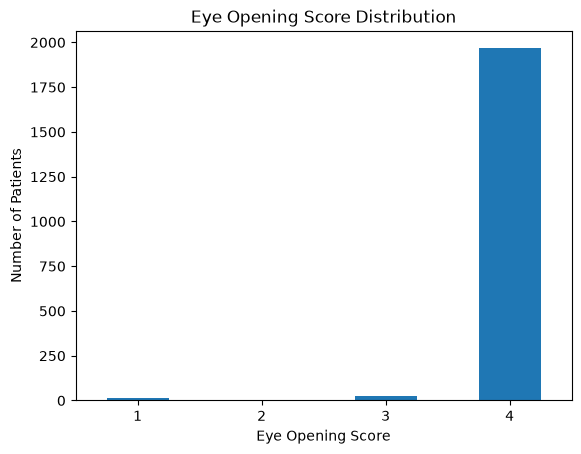

In [69]:
df_responsivenes['eye_opening'].value_counts().sort_index().plot(kind='bar')

plt.title('Eye Opening Score Distribution')
plt.xlabel('Eye Opening Score')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.show()

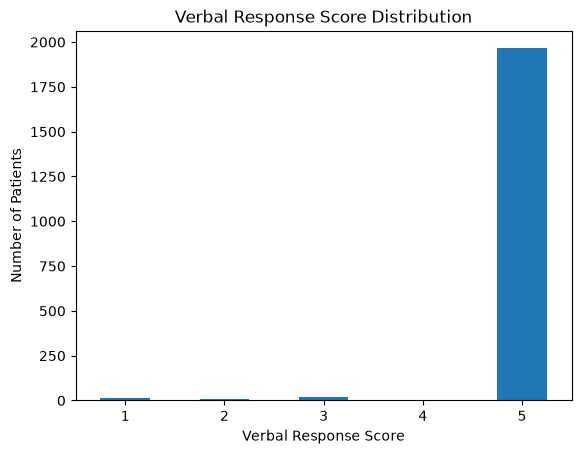

In [70]:
df_responsivenes['verbal_response'].value_counts().sort_index().plot(kind='bar')

plt.title('Verbal Response Score Distribution')
plt.xlabel('Verbal Response Score')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.show()

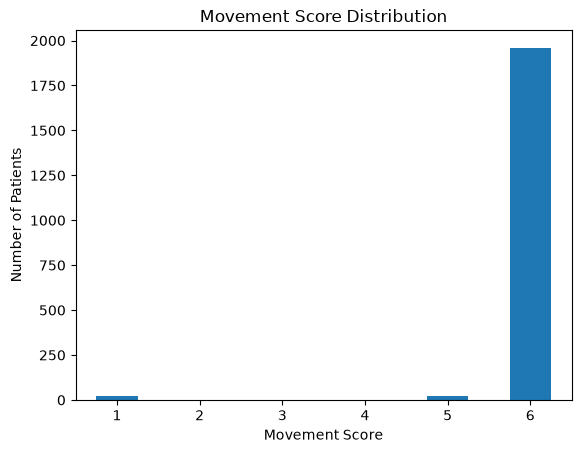

In [71]:
df_responsivenes['movement'].value_counts().sort_index().plot(kind='bar')

plt.title('Movement Score Distribution')
plt.xlabel('Movement Score')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.show()

In [72]:
df_responsivenes['consciousness'].value_counts()

consciousness
Clear                1974
ResponsiveToSound      19
Nonresponsive          11
ResponsiveToPain        4
Name: count, dtype: int64

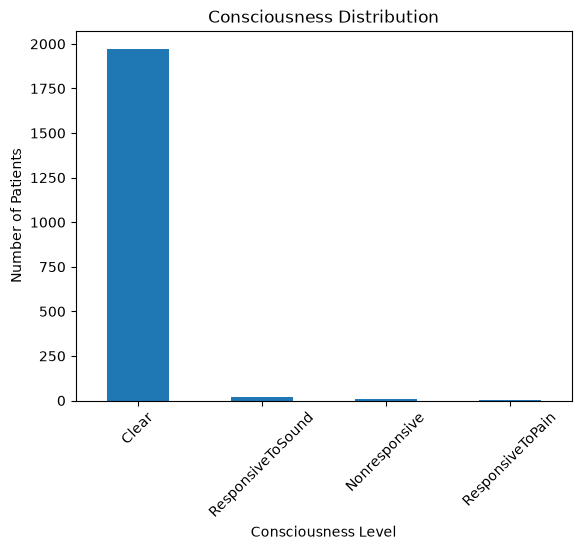

In [73]:
df_responsivenes['consciousness'].value_counts().plot(kind='bar')

plt.title('Consciousness Distribution')
plt.xlabel('Consciousness Level')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.show()

In [74]:
df_responsivenes['gcs'].value_counts().sort_index()

gcs
3       13
4        1
6        1
7        4
10       7
11      19
12       3
13       2
14       7
15    1951
Name: count, dtype: int64

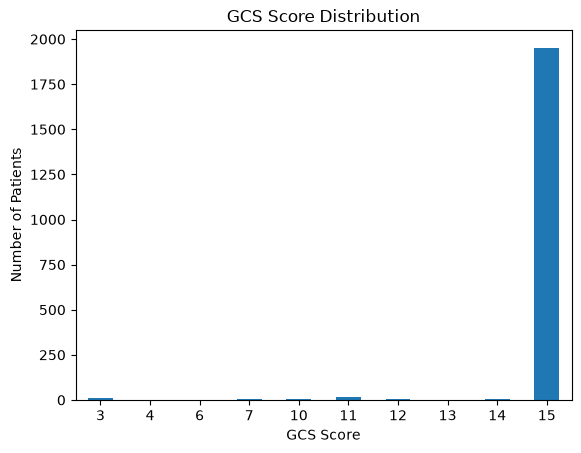

In [74]:
df_responsivenes['gcs'].value_counts().sort_index().plot(kind='bar')

plt.title('GCS Score Distribution')
plt.xlabel('GCS Score')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.show()


In [76]:
df_responsivenes['gcs'].min(), df_responsivenes['gcs'].max()

(np.int64(3), np.int64(15))

In [77]:
#gcs = eye_opening + verbal_response + movement.

In [78]:
df_responsivenes['calculated_gcs'] = (
    df_responsivenes['eye_opening'] +
    df_responsivenes['verbal_response'] +
    df_responsivenes['movement']
)

df_responsivenes[df_responsivenes['calculated_gcs'] != df_responsivenes['gcs']]

,inpatient_number,eye_opening,verbal_response,movement,consciousness,gcs,calculated_gcs


In [80]:
df_responsivenes[df_responsivenes['calculated_gcs'] != df_responsivenes['gcs']]

,inpatient_number,eye_opening,verbal_response,movement,consciousness,gcs,calculated_gcs


In [81]:
df_responsivenes[df_responsivenes['calculated_gcs'] != df_responsivenes['gcs']].shape

(0, 7)

In [82]:
df_responsivenes['movement'].min(), df_responsivenes['movement'].max()

(np.int64(1), np.int64(6))

In [83]:
#final data-cleaning checks instead of repeating anything

In [84]:
df_responsivenes['inpatient_number'].nunique()

2008

In [85]:
len(df_responsivenes)

2008

In [86]:
df_responsivenes.info()

<class 'pandas.DataFrame'>
RangeIndex: 2008 entries, 0 to 2007
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   inpatient_number  2008 non-null   int64
 1   eye_opening       2008 non-null   int64
 2   verbal_response   2008 non-null   int64
 3   movement          2008 non-null   int64
 4   consciousness     2008 non-null   str  
 5   gcs               2008 non-null   int64
 6   calculated_gcs    2008 non-null   int64
dtypes: int64(6), str(1)
memory usage: 120.1 KB


In [87]:
df_responsivenes.drop(columns=['calculated_gcs'], inplace=True)

In [88]:
df_responsivenes.columns.tolist()

['inpatient_number',
 'eye_opening',
 'verbal_response',
 'movement',
 'consciousness',
 'gcs']

In [93]:
df_responsivenes.to_csv("df_responsivenes_cleaned.csv", index=False)
df5_cleaned = pd.read_csv("cardiac_failure/df_responsivenes_cleaned.csv")
df5_cleaned.head

<bound method NDFrame.head of       inpatient_number  eye_opening  verbal_response  movement  consciousness  \
0               857781            4                5         6          Clear   
1               743087            4                5         6          Clear   
2               866418            4                5         6          Clear   
3               775928            4                5         6          Clear   
4               810128            4                5         6          Clear   
...                ...          ...              ...       ...            ...   
2003            740689            4                5         6          Clear   
2004            734280            4                5         6          Clear   
2005            781004            4                5         6          Clear   
2006            744870            1                1         1  Nonresponsive   
2007            791864            4                5         6          Clear  

In [89]:
#patienthistory.csv sudha

In [75]:
df_patienthistory = pd.read_csv("cardiac_failure/patienthistory.csv")

In [76]:
df_patienthistory["inpatient_number"] = df_patienthistory["inpatient_number"].astype(str)

In [91]:
df_patienthistory.head()

,inpatient_number,cerebrovascular_disease,dementia,chronic_obstructive_pulmonary_disease,connective_tissue_disease,peptic_ulcer_disease,diabetes,moderate_to_severe_chronic_kidney_disease,hemiplegia,leukemia,malignant_lymphoma,solid_tumor,liver_disease,aids,cci_score,type_ii_respiratory_failure,acute_renal_failure
0,857781,0,0,1,0,0.0,1,0.0,0,0,0,0,0.0,0,2.0,nontypeii,0
1,743087,0,0,0,0,0.0,0,0.0,0,0,0,0,0.0,0,0.0,nontypeii,0
2,866418,0,0,0,0,0.0,0,0.0,0,0,0,0,0.0,0,0.0,nontypeii,0
3,775928,0,0,1,0,0.0,0,1.0,0,0,0,0,0.0,0,2.0,nontypeii,0
4,810128,0,0,0,0,0.0,0,0.0,0,0,0,0,0.0,0,0.0,nontypeii,0


In [92]:
df_patienthistory.info()

<class 'pandas.DataFrame'>
RangeIndex: 2008 entries, 0 to 2007
Data columns (total 17 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   inpatient_number                           2008 non-null   int64  
 1   cerebrovascular_disease                    2008 non-null   int64  
 2   dementia                                   2008 non-null   int64  
 3   chronic_obstructive_pulmonary_disease      2008 non-null   int64  
 4   connective_tissue_disease                  2008 non-null   int64  
 5   peptic_ulcer_disease                       2006 non-null   float64
 6   diabetes                                   2008 non-null   int64  
 7   moderate_to_severe_chronic_kidney_disease  2006 non-null   float64
 8   hemiplegia                                 2008 non-null   int64  
 9   leukemia                                   2008 non-null   int64  
 10  malignant_lymphoma                 

In [93]:
df_patienthistory[df_patienthistory.isnull().any(axis=1)]

,inpatient_number,cerebrovascular_disease,dementia,chronic_obstructive_pulmonary_disease,connective_tissue_disease,peptic_ulcer_disease,diabetes,moderate_to_severe_chronic_kidney_disease,hemiplegia,leukemia,malignant_lymphoma,solid_tumor,liver_disease,aids,cci_score,type_ii_respiratory_failure,acute_renal_failure
467,782088,0,0,0,0,0.0,1,NaN,0,0,0,0,0.0,0,NaN,nontypeii,0
743,791916,0,0,0,0,0.0,1,NaN,0,0,0,0,0.0,0,NaN,nontypeii,1
817,794590,0,0,0,0,NaN,1,1.0,0,0,0,0,0.0,0,NaN,nontypeii,0
1003,818307,0,0,0,0,NaN,1,0.0,0,0,0,0,0.0,0,NaN,nontypeii,0
1497,793609,0,0,0,0,0.0,1,1.0,0,0,0,0,NaN,0,NaN,nontypeii,0


In [94]:
df_patienthistory["cci_score"].value_counts(dropna=False).sort_index()

cci_score
0.0     56
1.0    770
2.0    699
3.0    368
4.0     94
5.0     15
6.0      1
NaN      5
Name: count, dtype: int64

In [95]:
df_patienthistory[df_patienthistory["cci_score"].isnull()]

,inpatient_number,cerebrovascular_disease,dementia,chronic_obstructive_pulmonary_disease,connective_tissue_disease,peptic_ulcer_disease,diabetes,moderate_to_severe_chronic_kidney_disease,hemiplegia,leukemia,malignant_lymphoma,solid_tumor,liver_disease,aids,cci_score,type_ii_respiratory_failure,acute_renal_failure
467,782088,0,0,0,0,0.0,1,NaN,0,0,0,0,0.0,0,NaN,nontypeii,0
743,791916,0,0,0,0,0.0,1,NaN,0,0,0,0,0.0,0,NaN,nontypeii,1
817,794590,0,0,0,0,NaN,1,1.0,0,0,0,0,0.0,0,NaN,nontypeii,0
1003,818307,0,0,0,0,NaN,1,0.0,0,0,0,0,0.0,0,NaN,nontypeii,0
1497,793609,0,0,0,0,0.0,1,1.0,0,0,0,0,NaN,0,NaN,nontypeii,0


In [96]:

#5 rows where cci_score is missing. We should not guess those scores.

#There is also a fifth row (index 1497) where liver_disease is missing, so we need to inspect it separately.

In [77]:
df_patienthistory.groupby(
    ["diabetes", "cerebrovascular_disease", "dementia",
     "chronic_obstructive_pulmonary_disease",
     "connective_tissue_disease",
     "hemiplegia",
     "leukemia",
     "malignant_lymphoma",
     "solid_tumor",
     "aids"]
)["cci_score"].agg(["count", "mean", "median"]).head(20)

count  \
diabetes cerebrovascular_disease dementia chronic_obstructive_pulmonary_disease connective_tissue_disease hemiplegia leukemia malignant_lymphoma solid_tumor aids          
0        0                       0        0                                     0                         0          0        0                  0           0      1134   
                                                                                                                                                             1         3   
                                                                                                                                                 1           0        24   
                                                                                                          1          0        0                  0           0         1   
                                                                                1                         0          0        0                  0           0         2   
                                          1                                     0                         0          0        0                  0           0       169   
                                                                                                                                                 1           0         4   
                                                                                1                         0          0        0                  0           0         1   
                                                                                                                                                 1           0         1   
                                 1        0                                     0                         0          0        0                  0           0        90   
         1                       0        0                                     0                         0          0        0                  0           0        83   
                                                                                                                                                 1           0         1   
                                                                                                          1          0        0                  0           0         7   
                                          1                                     0                         0          0        0                  0           0        15   
                                                                                                                                                 1           0         1   
                                 1        0                                     0                         0          0        0                  0           0         6   
1        0                       0        0                                     0                         0          0        0                  0           0       356   
                                                                                                                                                             1         1   
                                                                                                                                                 1           0         7   
                                          1                                     0                         0          0        0                  0           0        40   

                                                                                                                                                                       mean  \
diabetes cerebrovascular_disease dementia chronic_obstructive_pulmonary_disease connective_tissue_disease hemiplegia leukemia malignant_lymphoma solid_tumor aids             
0        0                  

In [98]:
missing_cci = df_patienthistory[df_patienthistory["cci_score"].isna()]

missing_cci

,inpatient_number,cerebrovascular_disease,dementia,chronic_obstructive_pulmonary_disease,connective_tissue_disease,peptic_ulcer_disease,diabetes,moderate_to_severe_chronic_kidney_disease,hemiplegia,leukemia,malignant_lymphoma,solid_tumor,liver_disease,aids,cci_score,type_ii_respiratory_failure,acute_renal_failure
467,782088,0,0,0,0,0.0,1,NaN,0,0,0,0,0.0,0,NaN,nontypeii,0
743,791916,0,0,0,0,0.0,1,NaN,0,0,0,0,0.0,0,NaN,nontypeii,1
817,794590,0,0,0,0,NaN,1,1.0,0,0,0,0,0.0,0,NaN,nontypeii,0
1003,818307,0,0,0,0,NaN,1,0.0,0,0,0,0,0.0,0,NaN,nontypeii,0
1497,793609,0,0,0,0,0.0,1,1.0,0,0,0,0,NaN,0,NaN,nontypeii,0


In [99]:
df_patienthistory.loc[1497]

inpatient_number                                793609
cerebrovascular_disease                              0
dementia                                             0
chronic_obstructive_pulmonary_disease                0
connective_tissue_disease                            0
peptic_ulcer_disease                               0.0
diabetes                                             1
moderate_to_severe_chronic_kidney_disease          1.0
hemiplegia                                           0
leukemia                                             0
malignant_lymphoma                                   0
solid_tumor                                          0
liver_disease                                      NaN
aids                                                 0
cci_score                                          NaN
type_ii_respiratory_failure                  nontypeii
acute_renal_failure                                  0
Name: 1497, dtype: object

In [100]:
df_patienthistory.isnull().sum()


inpatient_number                             0
cerebrovascular_disease                      0
dementia                                     0
chronic_obstructive_pulmonary_disease        0
connective_tissue_disease                    0
peptic_ulcer_disease                         2
diabetes                                     0
moderate_to_severe_chronic_kidney_disease    2
hemiplegia                                   0
leukemia                                     0
malignant_lymphoma                           0
solid_tumor                                  0
liver_disease                                1
aids                                         0
cci_score                                    5
type_ii_respiratory_failure                  0
acute_renal_failure                          0
dtype: int64

In [102]:
#The patienthistory.csv dataset contains 10 missing values across four columns: peptic_ulcer_disease (2), moderate_to_severe_chronic_kidney_disease (2), liver_disease (1), and cci_score (5). Missing values were retained as NaN because the available
#data does not provide sufficient information to reliably determine the missing clinical values.

In [103]:
df_patienthistory.duplicated().sum()

np.int64(0)

In [104]:
df_patienthistory["inpatient_number"].duplicated().sum()

np.int64(0)

In [105]:
binary_columns = [
    "cerebrovascular_disease",
    "dementia",
    "chronic_obstructive_pulmonary_disease",
    "connective_tissue_disease",
    "peptic_ulcer_disease",
    "diabetes",
    "moderate_to_severe_chronic_kidney_disease",
    "hemiplegia",
    "leukemia",
    "malignant_lymphoma",
    "solid_tumor",
    "liver_disease",
    "aids",
    "acute_renal_failure"
]

for col in binary_columns:
    print(col, df_patienthistory[col].dropna().unique())

cerebrovascular_disease [0 1]
dementia [0 1]
chronic_obstructive_pulmonary_disease [1 0]
connective_tissue_disease [0 1]
peptic_ulcer_disease [0. 1.]
diabetes [1 0]
moderate_to_severe_chronic_kidney_disease [0. 1.]
hemiplegia [0 1]
leukemia [0]
malignant_lymphoma [0 1]
solid_tumor [0 1]
liver_disease [0. 1.]
aids [0 1]
acute_renal_failure [0 1]


In [106]:
df_patienthistory["type_ii_respiratory_failure"].value_counts(dropna=False)

type_ii_respiratory_failure
nontypeii    1894
typeii        114
Name: count, dtype: int64

In [107]:
df_patienthistory["cci_score"].dropna().unique()

array([2., 0., 1., 3., 4., 5., 6.])

In [108]:
df_patienthistory["cci_score"] = df_patienthistory["cci_score"].astype("Int64")



In [109]:
df_patienthistory["cci_score"].value_counts(dropna=False)

cci_score
1       770
2       699
3       368
4        94
0        56
5        15
<NA>      5
6         1
Name: count, dtype: Int64

In [110]:
binary_missing_cols = [
    "peptic_ulcer_disease",
    "moderate_to_severe_chronic_kidney_disease",
    "liver_disease"
]

for col in binary_missing_cols:
    df_patienthistory[col] = df_patienthistory[col].astype("Int64")

In [111]:
df_patienthistory[binary_missing_cols].info()

<class 'pandas.DataFrame'>
RangeIndex: 2008 entries, 0 to 2007
Data columns (total 3 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   peptic_ulcer_disease                       2006 non-null   Int64
 1   moderate_to_severe_chronic_kidney_disease  2006 non-null   Int64
 2   liver_disease                              2007 non-null   Int64
dtypes: Int64(3)
memory usage: 53.1 KB


In [112]:
print("Shape:", df_patienthistory.shape)

print("\nMissing values:")
print(df_patienthistory.isnull().sum())

print("\nDuplicate rows:", df_patienthistory.duplicated().sum())

print("Duplicate inpatient numbers:",
      df_patienthistory["inpatient_number"].duplicated().sum())

Shape: (2008, 17)

Missing values:
inpatient_number                             0
cerebrovascular_disease                      0
dementia                                     0
chronic_obstructive_pulmonary_disease        0
connective_tissue_disease                    0
peptic_ulcer_disease                         2
diabetes                                     0
moderate_to_severe_chronic_kidney_disease    2
hemiplegia                                   0
leukemia                                     0
malignant_lymphoma                           0
solid_tumor                                  0
liver_disease                                1
aids                                         0
cci_score                                    5
type_ii_respiratory_failure                  0
acute_renal_failure                          0
dtype: int64

Duplicate rows: 0
Duplicate inpatient numbers: 0


In [94]:
df_patienthistory.to_csv("df_patienthistory_cleaned.csv", index=False)
df6_cleaned = pd.read_csv("cardiac_failure/df_patienthistory_cleaned.csv")
df6_cleaned.head

<bound method NDFrame.head of       inpatient_number  cerebrovascular_disease  dementia  \
0               857781                        0         0   
1               743087                        0         0   
2               866418                        0         0   
3               775928                        0         0   
4               810128                        0         0   
...                ...                      ...       ...   
2003            740689                        0         0   
2004            734280                        0         0   
2005            781004                        0         0   
2006            744870                        0         0   
2007            791864                        0         0   

      chronic_obstructive_pulmonary_disease  connective_tissue_disease  \
0                                         1                          0   
1                                         0                          0   
2              

In [113]:
### Patient History Data Cleaning Summary
#The patient history dataset contains 2,008 records and 17 columns.
#Data cleaning included:
#- Checked the dataset structure and data types.
#- Checked and documented missing values.
#- Validated binary disease indicators to ensure values were 0 or 1.
#- Validated CCI scores, which ranged from 0 to 6.
#- Converted relevant columns to nullable integer (`Int64`) types while preserving missing values.
#- Verified that there are no duplicate rows.
#- Verified that there are no duplicate inpatient numbers.
#- Validated `type_ii_respiratory_failure` categories.
#A total of 10 missing values remain in four clinical columns. These values were retained as missing (`<NA>`) because there was insufficient information to reliably determine the missing clinical values.

In [114]:
#sudha work end pasent history

In [36]:
# Priya Demographics works starts here 

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Hackathon Data Cleaning Pipeline: Demographic Dataset

## Executive Overview
This notebook performs data cleaning, outlier handling, type casting, and feature engineering 
on the demographic patient dataset. 

### Data Quality Issues Addressed:
- Removal of corrupted baseline test records.
- Proper data type conversion for ID strings and categorical variables.
- Detection and correction of biologically impossible heights (< 1.0) 
- and weights (< 10.0 kg).
- Recalculation of Body Mass Index (BMI).
- Standardizing messy text entries and feature engineering clinical risk categories.


In [43]:
import numpy as np
import pandas as pd

In [44]:
# 1. Load raw dataset
df_demography = pd.read_csv("cardiac_failure/demography.csv")

In [45]:
# 2. Create working copy to preserve raw baseline
df_clean = df_demography.copy()

In [46]:
# 3. Baseline Audit
print(f"Dataset Dimensions: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
print("\n--- Initial Data Types ---")
print(df_clean.dtypes)
print("\n--- Initial Null Counts ---")
print(df_clean.isnull().sum())

Dataset Dimensions: 2009 rows, 7 columns

--- Initial Data Types ---
inpatient_number      int64
gender                  str
weight              float64
height              float64
bmi                 float64
occupation              str
agecat                  str
dtype: object

--- Initial Null Counts ---
inpatient_number     0
gender               1
weight               1
height               1
bmi                  0
occupation          28
agecat               1
dtype: int64


## Step 1: Record Filtering & Identifier Type Casting

### Actions:
1. **Remove Corrupted Test Row**: Row index 0 (`inpatient_number = 5`) is a dummy test 
   record containing `NaN` across all attributes with an isolated BMI value.
2. **Convert ID Data Type**: Convert `inpatient_number` from numerical `int64` to `str` 
   to avoid misidentifying patient IDs as quantitative numbers in statistical summaries.

In [48]:
# 1. Drop dummy/corrupted row
df_clean = df_clean[df_clean["inpatient_number"] != 5].copy()

# 2. Convert ID to string data type
df_clean["inpatient_number"] = df_clean["inpatient_number"].astype(str)

# Verify change
print(f"Updated Shape: {df_clean.shape}")
print(f"inpatient_number Data Type: {df_clean['inpatient_number'].dtype}")

Updated Shape: (2008, 7)
inpatient_number Data Type: str


## Step 2: Biological Outlier Detection & Calculation Fixes

### Actions:
1. **Flag Impossible Measurements**: 
   - Heights under 1.0 (0.35m - 0.60 m) are adult data entry errors and distort calculated BMIs (> 400).
   - Weights < 10.0 kg including 0.0 kg are invalid.
2. **Set Anomalies to `NaN`**: Replace invalid physical measurements with `NaN`.
3. **Recalculate BMI**: Recompute accurate BMIs using the standard formula:
   $$\text{BMI} = \frac{\text{Weight (kg)}}{\text{Height (m)}^2}$$

In [49]:
# 1. Create missingness flags for auditability
df_clean["flag_invalid_height"] = df_clean["height"] < 1.0
df_clean["flag_invalid_weight"] = df_clean["weight"] <= 10.0

# 2. Replace impossible entries with NaN
df_clean.loc[df_clean["flag_invalid_height"], "height"] = np.nan
df_clean.loc[df_clean["flag_invalid_weight"], "weight"] = np.nan

# 3. Recalculate true BMI
df_clean["bmi"] = df_clean["weight"] / (df_clean["height"] ** 2)

# Display summary statistics after cleanup
print("--- Sanitized BMI Summary Statistics ---")
print(df_clean["bmi"].describe())

--- Sanitized BMI Summary Statistics ---
count    2000.000000
mean       21.296969
std         3.807980
min        13.061224
25%        18.491124
50%        20.761246
75%        23.437500
max        39.111111
Name: bmi, dtype: float64


## Step 3: Categorical Standardization & Feature Engineering

### Actions:
1. **Standardize Text Fields**: Fix inconsistent casing in `occupation` (e.g., `farmer` $\rightar
`Farmer`, `UrbanResident` $\rightarrow$ `Urban Resident`) and handle missing values by filling 
them with `"Unspecified"`.
2. **Ordered Categorical Conversion**: Convert `agecat` into an ordered categorical data type 
(`21-29` < `29-39` < ... < `89-110`) to preserve correct age progression in charts.
3. **Feature Engineering**: Bin continuous BMI values into World Health Organization clinical
risk categories (`Underweight`, `Normal`, `Overweight`, `Obese`).

In [50]:
# 1. Standardize occupation names
occupation_map = {
    "farmer": "Farmer",
    "worker": "Worker",
    "UrbanResident": "Urban Resident",
    "Officer": "Officer",
    "Others": "Others",
}
df_clean["occupation"] = (
    df_clean["occupation"].map(occupation_map).fillna("Unspecified")
)

# 2. Set Gender categorical
df_clean["gender"] = df_clean["gender"].astype("category")

# 3. Set Ordered Categorical Age Ranges
age_order = [
    "21-29",
    "29-39",
    "39-49",
    "49-59",
    "59-69",
    "69-79",
    "79-89",
    "89-110",
]
df_clean["agecat"] = pd.Categorical(
    df_clean["agecat"], categories=age_order, ordered=True
)

# 4. Feature Engineering: Clinical BMI Risk Categories
bmi_bins = [0, 18.5, 24.9, 29.9, np.inf]
bmi_labels = ["Underweight", "Normal", "Overweight", "Obese"]
df_clean["bmi_category"] = pd.cut(
    df_clean["bmi"], bins=bmi_bins, labels=bmi_labels
)

# Check value distributions
print("--- Occupation Distribution ---")
print(df_clean["occupation"].value_counts())
print("\n--- BMI Risk Category Distribution ---")
print(df_clean["bmi_category"].value_counts())

--- Occupation Distribution ---
occupation
Urban Resident    1670
Farmer             198
Others              89
Unspecified         27
Worker              17
Officer              7
Name: count, dtype: int64

--- BMI Risk Category Distribution ---
bmi_category
Normal         1163
Underweight     507
Overweight      263
Obese            67
Name: count, dtype: int64


## Step 4: Final Validation & Export

### Actions:
1. Confirm final column data types and check remaining null counts.
2. Export the clean dataset to `Demography_Cleaned.csv` for downstream merging.

In [51]:
# 1. Final datatypes check
print("--- Final Data Types ---")
print(df_clean.dtypes)

# 2. Final missing value audit
print("\n--- Final Null Counts ---")
print(df_clean.isnull().sum())

# 3. Export cleaned data
df_clean.to_csv("Demography_Cleaned.csv", index=False)
print(
    f"\nDataset cleaned successfully! Output saved with shape {df_clean.shape}."
)

--- Final Data Types ---
inpatient_number            str
gender                 category
weight                  float64
height                  float64
bmi                     float64
occupation                  str
agecat                 category
flag_invalid_height        bool
flag_invalid_weight        bool
bmi_category           category
dtype: object

--- Final Null Counts ---
inpatient_number       0
gender                 0
weight                 4
height                 4
bmi                    8
occupation             0
agecat                 0
flag_invalid_height    0
flag_invalid_weight    0
bmi_category           8
dtype: int64

Dataset cleaned successfully! Output saved with shape (2008, 10).


#Check or Open the File Path Using Code
Run this quick code cell in Jupyter Notebook to display the exact folder path where your file was saved:

In [66]:
df_demography.to_csv("df_demography_cleaned.csv", index=False)
df10_cleaned = pd.read_csv("cardiac_failure/df_demography_cleaned.csv")
df10_cleaned.head

<bound method NDFrame.head of       inpatient_number  gender  weight  height        bmi     occupation  \
0                    5     NaN     NaN     NaN  46.000000            NaN   
1               827040  Female    50.0    1.45  23.781213            NaN   
2               857781    Male    50.0    1.64  18.590125  UrbanResident   
3               743087  Female    51.0    1.63  19.195303  UrbanResident   
4               866418    Male    70.0    1.70  24.221453         farmer   
...                ...     ...     ...     ...        ...            ...   
2004            740689  Female    35.0    1.50  15.555556         Others   
2005            734280  Female    50.0    1.55  20.811655  UrbanResident   
2006            781004    Male    75.0    1.70  25.951557  UrbanResident   
2007            744870    Male    40.0    1.50  17.777778  UrbanResident   
2008            791864  Female    45.0    1.55  18.730489  UrbanResident   

     agecat  
0       NaN  
1     69-79  
2     69-79  
3

#Priya Demography table Data cleaning ends here

#Priya Patient Presciption Data Cleaning starts here

# Hackathon Data Cleaning & Reshaping Pipeline: Patient Prescriptions Table

## Executive Overview
This notebook processes the `patient_prescriptions.csv` transactional dataset. 

### Key Processing Actions:
1. **Load & Copy**: Load the raw transactional data and create an isolated working copy.
2. **Identifier & Text Cleaning**: Convert `inpatient_number` to string data type and strip unintended whitespace from drug names.
3. **Reshaping (Long to Wide Format)**:
   - Compute the total medication burden (`total_prescriptions_count`) per patient.
   - One-hot encode the **25 exact unique drug names** directly from the raw dataset rows into binary columns (`1` = Prescribed, `0` = Not Prescribed) so each patient has exactly one row.
4. **Validation & Export**: Verify structural integrity and export the final patient-level table.

In [54]:
import numpy as np
import pandas as pd

# 1. Load raw dataset (adjust folder path if your file is inside a subfolder like 'cardiac_failure/')
df_prescriptions_raw = pd.read_csv("cardiac_failure/patient_precriptions.csv")

# 2. Create a working copy to preserve raw data in memory
df_rx = df_prescriptions_raw.copy()

# 3. Baseline Audit
print(f"Raw Dataset Dimensions: {df_rx.shape[0]} rows, {df_rx.shape[1]} columns")
print(f"Unique Patients Count: {df_rx['inpatient_number'].nunique()}")
print(f"Unique Drug Names Count: {df_rx['drug_name'].nunique()}")
print("\n--- Initial Null Values Audit ---")
print(df_rx.isnull().sum())

Raw Dataset Dimensions: 15362 rows, 2 columns
Unique Patients Count: 2007
Unique Drug Names Count: 25

--- Initial Null Values Audit ---
inpatient_number    0
drug_name           0
dtype: int64


## Step 1: Identifier Type Casting & Text Standardization

### Actions:
1. Convert `inpatient_number` from `int64` to `str` to ensure consistent keys when merging with Demography and Clinical tables.
2. Strip unexpected leading/trailing whitespaces from `drug_name` strings to prevent text formatting mismatches.

In [55]:
# 1. Convert patient ID to string data type
df_rx["inpatient_number"] = df_rx["inpatient_number"].astype(str)

# 2. Clean whitespace in drug names
df_rx["drug_name"] = df_rx["drug_name"].str.strip()

# Verify data type change
print(f"inpatient_number Data Type: {df_rx['inpatient_number'].dtype}")

inpatient_number Data Type: str


## Step 2: Aggregation & Reshaping (Long Format to Wide Format)

### Actions:
Machine learning models require **one row per patient**. We transform the transactional rows using:
1. **Total Prescription Count**: Group by `inpatient_number` to calculate total prescriptions per patient (`total_prescriptions_count`).
2. **One-Hot Encoding (Pivot)**: Pivot the 25 exact drug names present in the raw data into binary indicator columns (`1` or `0`).
3. **Merge Features**: Combine count and individual drug flags into a unified 1-row-per-patient dataset (**27 columns total**).

## Step 3: Reshaping from Long Format to Patient-Level Wide Format

### Actions:
1. **Total Medication Count**: Calculate total number of drugs prescribed to each patient (`total_prescriptions_count`).
2. **One-Hot Encoding**: Pivot individual drug names into binary indicator columns (`1` = Prescribed, `0` = Not Prescribed).
3. **Class Indicator Encoding**: Pivot therapeutic drug classes into binary flags (`1` = On Class Therapy, `0` = Not On Class Therapy).

In [56]:
# 1. Calculate total prescription count per patient
df_patient_count = (
    df_rx.groupby("inpatient_number")["drug_name"]
    .count()
    .reset_index(name="total_prescriptions_count")
)

# 2. One-Hot Encode the exact 25 drug names directly from dataset rows
df_drugs_pivot = (
    pd.crosstab(df_rx["inpatient_number"], df_rx["drug_name"])
    .clip(upper=1)
    .reset_index()
)

# Clean drug column names for pythonic access (spaces/hyphens converted to underscores with 'rx_' prefix)
df_drugs_pivot.columns = [
    col if col == "inpatient_number" else f"rx_{col.lower().replace(' ', '_')}"
    for col in df_drugs_pivot.columns
]

# 3. Merge into a single Patient-Level Wide Table
df_prescriptions_patient_level = df_patient_count.merge(
    df_drugs_pivot, on="inpatient_number"
)

# Display transformed structure
print("Transformed Patient-Level Prescriptions Table Preview:")
print(f"Shape: {df_prescriptions_patient_level.shape} (Expected: 2007 rows, 27 columns)")
df_prescriptions_patient_level.head()

Transformed Patient-Level Prescriptions Table Preview:
Shape: (2007, 27) (Expected: 2007 rows, 27 columns)


,inpatient_number,total_prescriptions_count,rx_aspirin_enteric-coated_tablet,rx_atorvastatin_calcium_tablet,rx_benazepril_hydrochloride_tablet,rx_clopidogrel_hydrogen_sulphate_tablet,rx_deslanoside_injection,rx_digoxin_tablet,rx_dobutamine_hydrochloride_injection,rx_enoxaparin_sodium_injection,...,rx_metoprolol_succinate_sustained-release_tablet,rx_milrinone_injection,rx_nitroglycerin_injection,rx_shenfu_injection,rx_spironolactone_tablet,rx_torasemide_tablet,rx_valsartan_dispersible_tablet,rx_metoprolol_tartrate_injection,rx_sulfotanshinone_sodium_injection,rx_warfarin_sodium_tablet
0,722128,7,0,0,0,0,1,1,0,0,...,0,1,0,0,1,0,0,0,0,1
1,723327,12,1,1,0,1,1,1,0,0,...,0,1,0,0,1,1,1,0,0,0
2,723617,4,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,724385,6,0,0,0,0,1,1,0,0,...,0,1,0,0,1,0,0,0,0,0
4,725509,9,0,0,0,0,1,1,0,0,...,0,1,0,1,1,1,0,1,0,0


## Step 3: Final Validation, Path Inspection & Export

### Actions:
1. Validate that the patient count equals 2,007 unique patients and check for missing values.
2. Export the clean dataset to `Patient_Prescriptions_Cleaned.csv` in your working directory.
3. Print the exact file save path to confirm location.

In [79]:
df_prescriptions_patient_level.to_csv(
    "df_Patient_Prescriptions_Cleaned.csv", index=False
)
df11_cleaned = pd.read_csv("cardiac_failure/df_Patient_Prescriptions_Cleaned.csv")
df11_cleaned.head

<bound method NDFrame.head of       inpatient_number  total_prescriptions_count  \
0               722128                          7   
1               723327                         12   
2               723617                          4   
3               724385                          6   
4               725509                          9   
...                ...                        ...   
2002            870258                          8   
2003            870646                          6   
2004            879601                         13   
2005            905163                         11   
2006            905720                          9   

      rx_aspirin_enteric-coated_tablet  rx_atorvastatin_calcium_tablet  \
0                                    0                               0   
1                                    1                               1   
2                                    0                               1   
3                                    

In [58]:
import os

# 1. Validation Checks
assert (
    df_prescriptions_patient_level["inpatient_number"].nunique() == 2007
), "Patient count mismatch!"
assert (
    df_prescriptions_patient_level.isnull().sum().sum() == 0
), "Null values found in transformed table!"

# 2. Export clean CSV
output_filename = "Patient_Prescriptions_Cleaned.csv"
df_prescriptions_patient_level.to_csv(output_filename, index=False)


# 3. Verification & Absolute File Path Display
print("--- Export Summary ---")
print(f"File Saved Successfully: {os.path.exists(output_filename)}")
print(f"Absolute File Path: {os.path.abspath(output_filename)}")
print(f"Final Output Shape: {df_prescriptions_patient_level.shape}")
print(f"Total Columns Count: {df_prescriptions_patient_level.shape[1]}")

--- Export Summary ---
File Saved Successfully: True
Absolute File Path: C:\Users\apriy\Documents\GitHub\Team4_The_Zen_OF_Five_PythonHackathon_Sep2026\Patient_Prescriptions_Cleaned.csv
Final Output Shape: (2007, 27)
Total Columns Count: 27


In [ ]:
#Priya Patient Prescription code ends here